# GNN 사기 탐지 — 05. PC-GNN

## 설계 개요

| 항목 | PC-GNN |
|------|--------|
| **피처** | 행동피처 8개 + TF-IDF SVD 64차원 = 72차원 |
| **엣지** | R-U-R + R-S-R + R-P-R + R-Sim-R (4종) |
| **집계** | Chooser 어텐션 (위장 이웃 억제) |
| **배치** | Picker — 사기 전량 + 정상 3배 |
| **손실** | FocalLoss (γ=2.0) + class weight |
| **분할** | 유저 단위 (R-U-R 라벨 누수 차단) |

04 Baseline(ReviewRGCN, 동질 그래프)에서 R-U-R 관계 추가 + Chooser 어텐션 + Picker 샘플링으로 고도화한 모델.

결과는 `results_05.json`으로 저장됩니다.

In [1]:
# [00] 임포트 및 환경 설정
import os, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, average_precision_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import MessagePassing, RGCNConv
from torch_geometric.utils import to_undirected

# 노트북 실행 위치를 작업 디렉토리로 자동 설정 (하드코딩 제거)
BASE_DIR = str(Path().resolve())
os.chdir(BASE_DIR)
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'환경 설정 완료 | 디바이스: {device}')
print(f'   PyTorch: {torch.__version__}')
print(f'   작업 디렉토리: {BASE_DIR}')

환경 설정 완료 | 디바이스: cpu
   PyTorch: 2.11.0+cpu
   작업 디렉토리: C:\Users\bella\Desktop\대학\CODE\GNN 학술제


In [2]:
# [01] 하이퍼파라미터 설정
CFG = {
    'random_state': 42,
    # 텍스트 임베딩
    'tfidf_max_features': 5000,
    'svd_n_components':   64,
    # 유저 단위 분할 비율
    'train_user_ratio': 0.60,
    'val_user_ratio':   0.20,   # test = 나머지 0.20
    # 엣지 샘플링 — 상한 설정으로 heavy user 폭발 방지
    'rur_max_per_node':  10,    # R-U-R: 노드당 최대 10개 이웃 (CPU 속도 최적화)
    'rsr_max_per_node':   5,
    'rpr_max_per_node':   8,
    'rsim_thr':           0.70,
    # 모델 — hidden 64로 어텐션 연산 4× 감소
    'hidden_dim':  64,
    'dropout':     0.40,
    # 학습
    'lr':       5e-4,
    'wd':       5e-4,
    'epochs':   60,
    'patience': 10,
    # PC-GNN 특화
    'picker_ratio': 3,    # 배치 내 정상:사기 = 3:1
    'focal_gamma':  2.0,
}
print('✅ 설정 완료')
print(f"   유저 분할: train {CFG['train_user_ratio']*100:.0f}% / val {CFG['val_user_ratio']*100:.0f}% / test 나머지")
print(f"   Picker ratio={CFG['picker_ratio']}  |  Focal gamma={CFG['focal_gamma']}")
print(f"   hidden_dim={CFG['hidden_dim']}  |  R-U-R max_per_node={CFG['rur_max_per_node']}  |  epochs={CFG['epochs']}")

✅ 설정 완료
   유저 분할: train 60% / val 20% / test 나머지
   Picker ratio=3  |  Focal gamma=2.0
   hidden_dim=64  |  R-U-R max_per_node=10  |  epochs=60


In [3]:
# [02] 데이터 로드
print('데이터 로드 중...')
df = pd.read_parquet('yelpzip_sampled.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

assert set(df['label'].unique()).issubset({0, 1}), '라벨 변환 필요!'
N = len(df)
labels = df['label'].values
n_fraud = labels.sum()
print(f'✅ 데이터: {N:,}건  | 사기: {n_fraud:,} ({100*n_fraud/N:.1f}%)  | 정상: {N-n_fraud:,}')
print(f'   기간: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'   유저: {df["user_id"].nunique():,}명  | 식당: {df["prod_id"].nunique():,}개')

데이터 로드 중...
✅ 데이터: 50,950건  | 사기: 12,659 (24.8%)  | 정상: 38,291
   기간: 2013-01-01 ~ 2014-12-31
   유저: 17,439명  | 식당: 200개


In [4]:
# [03] TF-IDF + SVD 텍스트 임베딩 (임시 train 인덱스로 fit)
_users = df['user_id'].unique().copy()
np.random.seed(CFG['random_state'])
np.random.shuffle(_users)
_n_tr     = int(len(_users) * CFG['train_user_ratio'])
_fit_idx  = df.index[df['user_id'].isin(set(_users[:_n_tr]))].to_numpy()

print('TF-IDF + SVD 임베딩 중...')
t0 = time.time()
tfidf = TfidfVectorizer(
    max_features=CFG['tfidf_max_features'], ngram_range=(1,2),
    min_df=3, max_df=0.95, strip_accents='unicode', sublinear_tf=True
)
tfidf.fit(df['text'].astype(str).values[_fit_idx])
tfidf_mat  = tfidf.transform(df['text'].astype(str))

svd = TruncatedSVD(n_components=CFG['svd_n_components'], random_state=CFG['random_state'])
svd.fit(tfidf_mat[_fit_idx])
text_embed = svd.transform(tfidf_mat).astype(np.float32)
print(f'✅ 임베딩 완료 ({time.time()-t0:.0f}s) | 설명 분산: {svd.explained_variance_ratio_.sum():.3f}')

TF-IDF + SVD 임베딩 중...
✅ 임베딩 완료 (34s) | 설명 분산: 0.128


In [5]:
# [04] 유저 단위 Train / Val / Test 분리
# R-U-R 라벨 누수 차단: 동일 유저 모든 리뷰가 같은 파티션에 배치됨
users = df['user_id'].unique()
np.random.seed(CFG['random_state'])
np.random.shuffle(users)
n_users = len(users)

n_train = int(n_users * CFG['train_user_ratio'])
n_val   = int(n_users * CFG['val_user_ratio'])

train_users = set(users[:n_train])
val_users   = set(users[n_train:n_train+n_val])
test_users  = set(users[n_train+n_val:])

idx_train = df.index[df['user_id'].isin(train_users)].to_numpy()
idx_val   = df.index[df['user_id'].isin(val_users)].to_numpy()
idx_test  = df.index[df['user_id'].isin(test_users)].to_numpy()

train_mask = torch.zeros(N, dtype=torch.bool); train_mask[idx_train] = True
val_mask   = torch.zeros(N, dtype=torch.bool); val_mask[idx_val]     = True
test_mask  = torch.zeros(N, dtype=torch.bool); test_mask[idx_test]   = True

df_train = df.iloc[idx_train]
print(f'Train: {len(idx_train):,}건  사기율: {labels[idx_train].mean():.3f}  ({len(train_users):,}명 유저)')
print(f'Val  : {len(idx_val):,}건  사기율: {labels[idx_val].mean():.3f}  ({len(val_users):,}명 유저)')
print(f'Test : {len(idx_test):,}건  사기율: {labels[idx_test].mean():.3f}  ({len(test_users):,}명 유저)')
print('✅ 유저 단위 분리 완료 — train/val/test 간 R-U-R 엣지 없음')

Train: 30,620건  사기율: 0.246  (10,463명 유저)
Val  : 9,912건  사기율: 0.260  (3,487명 유저)
Test : 10,418건  사기율: 0.243  (3,489명 유저)
✅ 유저 단위 분리 완료 — train/val/test 간 R-U-R 엣지 없음


In [6]:
# [05] 사용자 통계 피처 (Train 전용 → 누수 방지)
print('사용자 통계 계산 중...')
user_stats = df_train.groupby('user_id').agg(
    user_review_count = ('label', 'count'),
    user_avg_rating   = ('rating', 'mean'),
    user_rating_std   = ('rating', lambda x: float(x.std()) if len(x)>1 else 0.0),
    activity_span     = ('date',   lambda x: float((x.max()-x.min()).days)),
).reset_index()
user_stats.fillna(0, inplace=True)

burst_df = pd.read_csv('burst_features.csv', index_col=0).reset_index()
burst_df.columns = ['user_id','user_burst_max7d','user_burst_ratio']
user_stats = user_stats.merge(burst_df, on='user_id', how='left')
user_stats[['user_burst_max7d','user_burst_ratio']] = user_stats[['user_burst_max7d','user_burst_ratio']].fillna(0)
print(f'✅ 사용자 통계 완료: {len(user_stats):,}명')

사용자 통계 계산 중...
✅ 사용자 통계 완료: 10,463명


In [7]:
# [06] 피처 행렬 조립 (PC-GNN: 행동 8개 + TF-IDF SVD 64차원 = 72차원)
df_feat = df[['user_id','prod_id','rating','date','label']].copy().reset_index(drop=True)

user_cols = ['user_id','user_review_count','user_avg_rating','user_rating_std',
             'activity_span','user_burst_max7d','user_burst_ratio']
df_feat = df_feat.merge(user_stats[user_cols], on='user_id', how='left')

fr = pd.read_csv('features_rating.csv', index_col=0)
fr_dedup = fr[['user_id','prod_id','rating_deviation','is_cold_start','is_single_review']].drop_duplicates(subset=['user_id','prod_id'])
df_feat = df_feat.merge(fr_dedup, on=['user_id','prod_id'], how='left')
df_feat.fillna(0, inplace=True)
df_feat['user_avg_rating'] = df_feat['user_avg_rating'].replace(0, df_train['rating'].mean())

# rpr_suspicion — R-P-R 엣지 및 노드 피처용
rating_dev = df_feat['rating_deviation'].fillna(0).values
df_feat['rpr_suspicion'] = np.abs(rating_dev)
# 장기 충성 고객 화이트리스트
whitelist = (df_feat['activity_span'].fillna(0) >= 365) & (df_feat['user_review_count'].fillna(0) >= 10)
df_feat.loc[whitelist, 'rpr_suspicion'] = 0.0

BEHAV_COLS = [
    'rating', 'user_review_count', 'user_avg_rating', 'user_rating_std',
    'activity_span', 'user_burst_max7d', 'is_cold_start', 'is_single_review',
]
scaler    = StandardScaler()
scaler.fit(df_feat[BEHAV_COLS].values[idx_train])
behav_mat = scaler.transform(df_feat[BEHAV_COLS].values).astype(np.float32)
X_pcgnn   = np.hstack([behav_mat, text_embed])
X_pcgnn   = np.nan_to_num(X_pcgnn, nan=0.0, posinf=0.0, neginf=0.0)

x_pcgnn      = torch.tensor(X_pcgnn, dtype=torch.float32)
y            = torch.tensor(labels,  dtype=torch.long)
in_dim_pcgnn = x_pcgnn.shape[1]

print('✅ 피처 조립 완료')
print(f'   PC-GNN 피처: {in_dim_pcgnn}차원  (행동 {len(BEHAV_COLS)}개 + SVD {CFG["svd_n_components"]}차원)')

✅ 피처 조립 완료
   PC-GNN 피처: 72차원  (행동 8개 + SVD 64차원)


In [8]:
# [07] 엣지 구성 (PC-GNN 4종)
df['ym'] = df['date'].dt.to_period('M')
rng = np.random.default_rng(42)

susp_scores       = df_feat['rpr_suspicion'].values
rating_dev_scores = np.abs(df_feat['rating_deviation'].fillna(0).values)

def make_pairs(groups, max_per_node=None):
    src, dst = [], []
    for nodes in groups:
        nodes = list(nodes)
        if len(nodes) < 2: continue
        n_pairs = len(nodes)*(len(nodes)-1)//2
        if max_per_node is None or n_pairs <= max_per_node*len(nodes):
            for i in range(len(nodes)):
                for j in range(i+1, len(nodes)):
                    src.append(nodes[i]); dst.append(nodes[j])
        else:
            for node in nodes:
                others = [n for n in nodes if n != node]
                k = min(max_per_node, len(others))
                for j in rng.choice(others, k, replace=False):
                    src.append(node); dst.append(int(j))
    return np.array(src, dtype=np.int64), np.array(dst, dtype=np.int64)

def make_pairs_scored(groups, scores, max_per_node):
    src, dst = [], []
    for nodes in groups:
        nodes = list(nodes)
        if len(nodes) < 2: continue
        n_pairs = len(nodes)*(len(nodes)-1)//2
        if n_pairs <= max_per_node*len(nodes):
            for i in range(len(nodes)):
                for j in range(i+1, len(nodes)):
                    src.append(nodes[i]); dst.append(nodes[j])
        else:
            sorted_nodes = [nodes[i] for i in np.argsort(-scores[nodes])]
            for node in nodes:
                others = [n for n in sorted_nodes if n != node]
                k = min(max_per_node, len(others))
                for j in others[:k]:
                    src.append(node); dst.append(j)
    return np.array(src, dtype=np.int64), np.array(dst, dtype=np.int64)

def to_edge(s, d, n):
    if len(s) == 0: return torch.zeros((2,0), dtype=torch.long)
    ei = torch.tensor(np.stack([s,d], axis=0), dtype=torch.long)
    ei = to_undirected(ei, num_nodes=n)
    return ei[:, ei[0] != ei[1]]

t0 = time.time()
print(f'엣지 구성 중... (N={N:,})')

# R-U-R: max_per_node 제한으로 heavy user 엣지 폭발 방지
s, d = make_pairs(
    df.groupby('user_id').apply(lambda x: x.index.tolist()).values,
    max_per_node=CFG['rur_max_per_node'])
edge_rur = to_edge(s, d, N)
print(f'  R-U-R   : {edge_rur.size(1):>8,}개  (노드당 최대 {CFG["rur_max_per_node"]}개)')

# R-S-R: rating_deviation 높은 순 우선
s, d = make_pairs_scored(
    df.groupby(['prod_id','rating']).apply(lambda x: x.index.tolist()).values,
    rating_dev_scores, max_per_node=CFG['rsr_max_per_node'])
edge_rsr = to_edge(s, d, N)
print(f'  R-S-R   : {edge_rsr.size(1):>8,}개  (rating_deviation 우선)')

# R-P-R: rpr_suspicion 높은 순 우선
susp_mask = df_feat['rpr_suspicion'].values > 0
df_susp   = df[susp_mask].copy()
s, d = make_pairs_scored(
    df_susp.groupby('prod_id').apply(lambda x: x.index.tolist()).values,
    susp_scores, max_per_node=CFG['rpr_max_per_node'])
edge_rpr = to_edge(s, d, N)
print(f'  R-P-R   : {edge_rpr.size(1):>8,}개  (의심도 우선)')

# R-Sim-R: 텍스트 유사도
sim_df = pd.read_csv('custom_edges_textSim.csv')
sim_df = sim_df[sim_df['text_similarity'] >= CFG['rsim_thr']]
valid  = (sim_df['src_review_idx'] < N) & (sim_df['dst_review_idx'] < N)
sim_df = sim_df[valid]
edge_rsim = to_edge(
    sim_df['src_review_idx'].values.astype(np.int64),
    sim_df['dst_review_idx'].values.astype(np.int64), N)
print(f'  R-Sim-R : {edge_rsim.size(1):>8,}개  (유사도 ≥{CFG["rsim_thr"]})')

edge_indices_pcgnn = [edge_rur, edge_rsr, edge_rpr, edge_rsim]
REL_NAMES = ['R-U-R', 'R-S-R', 'R-P-R', 'R-Sim-R']

total_edges = sum(e.size(1) for e in edge_indices_pcgnn)
print(f'\n✅ 엣지 구성 완료 ({time.time()-t0:.0f}s) | 총 {total_edges:,}개 (4종)')

엣지 구성 중... (N=50,950)
  R-U-R   :  254,784개  (노드당 최대 10개)
  R-S-R   :  481,794개  (rating_deviation 우선)
  R-P-R   :  724,080개  (의심도 우선)
  R-Sim-R :  319,670개  (유사도 ≥0.7)

✅ 엣지 구성 완료 (3s) | 총 1,780,328개 (4종)


In [9]:
# [08] 모델 정의 (FocalLoss + ChooserConv + PCGNN)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class ChooserConv(MessagePassing):
    """이웃별 어텐션으로 위장 정상 이웃 억제."""
    def __init__(self, in_ch, out_ch):
        super().__init__(aggr='add')
        self.lin  = nn.Linear(in_ch, out_ch, bias=False)
        self.attn = nn.Linear(2 * out_ch, 1)
        self.norm = nn.LayerNorm(out_ch)
        nn.init.xavier_uniform_(self.lin.weight)

    def forward(self, x, edge_index):
        if edge_index.size(1) == 0:
            return self.norm(torch.zeros(x.size(0), self.lin.weight.size(0), device=x.device))
        x_lin = self.lin(x)
        out   = self.propagate(edge_index, x=x_lin)
        return self.norm(out)

    def message(self, x_i, x_j):
        alpha = torch.sigmoid(self.attn(torch.cat([x_i, x_j], dim=-1)))
        return alpha * x_j


class PCGNN(nn.Module):
    """4관계 Chooser 어텐션 + Picker 샘플링 기반 사기 탐지."""
    def __init__(self, in_dim, hidden_dim=128, n_rel=4, n_class=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ELU()
        )
        self.drop       = nn.Dropout(dropout)
        self.choosers1  = nn.ModuleList([ChooserConv(hidden_dim, hidden_dim) for _ in range(n_rel)])
        self.choosers2  = nn.ModuleList([ChooserConv(hidden_dim, hidden_dim) for _ in range(n_rel)])
        self.inter_attn = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.Tanh(), nn.Linear(32, 1, bias=False)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ELU(),
            nn.Dropout(dropout), nn.Linear(64, n_class)
        )

    def forward(self, x, edge_indices):
        h   = self.drop(self.input_proj(x))
        h1  = [F.elu(self.drop(c(h,   ei))) for c, ei in zip(self.choosers1, edge_indices)]
        h2  = [F.elu(self.drop(c(h1i, ei))) for c, h1i, ei in zip(self.choosers2, h1, edge_indices)]
        stk  = torch.stack(h2, dim=1)
        attn = torch.softmax(self.inter_attn(stk).squeeze(-1), dim=1)
        h_agg = (stk * attn.unsqueeze(-1)).sum(dim=1)
        return self.classifier(h_agg), attn.detach().mean(dim=0)


_p = PCGNN(in_dim_pcgnn, CFG['hidden_dim'], 4, dropout=CFG['dropout'])
print('✅ 모델 정의 완료  (FocalLoss + ChooserConv + PCGNN)')
print(f'   PCGNN 파라미터: {sum(p.numel() for p in _p.parameters() if p.requires_grad):,}개')
del _p

✅ 모델 정의 완료  (FocalLoss + ChooserConv + PCGNN)
   PCGNN 파라미터: 46,026개


In [10]:
# [09] 학습 유틸리티

def picker_sample(idx_train, labels, ratio, N):
    """사기 전량 + 정상 ratio배 샘플링."""
    fraud_idx  = idx_train[labels[idx_train] == 1]
    normal_idx = idx_train[labels[idx_train] == 0]
    n_sample   = min(len(fraud_idx) * ratio, len(normal_idx))
    sampled    = np.random.choice(normal_idx, n_sample, replace=False)
    picked     = np.concatenate([fraud_idx, sampled])
    mask = torch.zeros(N, dtype=torch.bool)
    mask[picked] = True
    return mask

def eval_pcgnn(model, x, edge_list, y, mask):
    model.eval()
    with torch.no_grad():
        logits, _ = model(x, edge_list)
        probs     = torch.softmax(logits, dim=1)[:, 1]
        preds     = logits.argmax(dim=1)
    yt, yp, yprob = y[mask].numpy(), preds[mask].numpy(), probs[mask].numpy()
    return average_precision_score(yt, yprob), f1_score(yt, yp, average='macro'), yt, yp, yprob

def bar(v, L=28): return '█'*int(v*L) + '░'*(L-int(v*L))

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=labels[idx_train])
print('✅ 유틸리티 준비 완료')
print(f'   클래스 가중치: 정상={cw[0]:.3f}  사기={cw[1]:.3f}')
print(f'   Picker: 사기 전량 + 정상 {CFG["picker_ratio"]}배 → 배치 사기율 {1/(1+CFG["picker_ratio"]):.2f}')

✅ 유틸리티 준비 완료
   클래스 가중치: 정상=0.664  사기=2.029
   Picker: 사기 전량 + 정상 3배 → 배치 사기율 0.25


In [11]:
# [10] PC-GNN 학습
print('='*62)
print(' PC-GNN 학습')
print(f' 피처: 행동 {len(BEHAV_COLS)}개 + SVD {CFG["svd_n_components"]}차원 = {in_dim_pcgnn}차원')
print(' 엣지: R-U-R + R-S-R + R-P-R + R-Sim-R (4종) | Chooser 어텐션')
print(f' 배치: Picker ratio={CFG["picker_ratio"]}  |  FocalLoss gamma={CFG["focal_gamma"]}')
print('='*62)

cw_p    = compute_class_weight('balanced', classes=np.array([0,1]), y=labels[idx_train])
cw_p[1] *= 1.5
crit_p  = FocalLoss(alpha=torch.tensor(cw_p, dtype=torch.float32), gamma=CFG['focal_gamma'])

pcgnn_model = PCGNN(in_dim=in_dim_pcgnn, hidden_dim=CFG['hidden_dim'], n_rel=4, dropout=CFG['dropout'])
opt_p = AdamW(pcgnn_model.parameters(), lr=CFG['lr'], weight_decay=CFG['wd'])
sch_p = CosineAnnealingLR(opt_p, T_max=CFG['epochs'])

best_p_pr, best_p_state, no_imp_p = 0.0, None, 0
t0 = time.time()

for ep in range(1, CFG['epochs']+1):
    picked_mask = picker_sample(idx_train, labels, CFG['picker_ratio'], N)

    pcgnn_model.train(); opt_p.zero_grad()
    logits, _ = pcgnn_model(x_pcgnn, edge_indices_pcgnn)
    loss = crit_p(logits[picked_mask], y[picked_mask])
    loss.backward(); nn.utils.clip_grad_norm_(pcgnn_model.parameters(), 1.0); opt_p.step()
    sch_p.step()

    if ep % 10 == 0:
        vpr, vf1, *_ = eval_pcgnn(pcgnn_model, x_pcgnn, edge_indices_pcgnn, y, val_mask)
        print(f'  [E{ep:3d}] loss={float(loss):.4f} | val PR-AUC={vpr:.4f} F1={vf1:.4f} ({time.time()-t0:.0f}s)')
        if vpr > best_p_pr:
            best_p_pr = vpr
            best_p_state = {k: v.clone() for k,v in pcgnn_model.state_dict().items()}
            no_imp_p = 0
        else:
            no_imp_p += 1
            if no_imp_p >= CFG['patience']:
                print('  Early stopping'); break

pcgnn_model.load_state_dict(best_p_state)
res_p_pr, res_p_f1, yt_p, yp_p, yprob_p = eval_pcgnn(
    pcgnn_model, x_pcgnn, edge_indices_pcgnn, y, test_mask)
torch.save(best_p_state, 'best_pcgnn.pt')
print(f'\n✅ PC-GNN 최종:  PR-AUC={res_p_pr:.4f}  Macro F1={res_p_f1:.4f}')

 PC-GNN 학습
 피처: 행동 8개 + SVD 64차원 = 72차원
 엣지: R-U-R + R-S-R + R-P-R + R-Sim-R (4종) | Chooser 어텐션
 배치: Picker ratio=3  |  FocalLoss gamma=2.0
  [E 10] loss=0.2677 | val PR-AUC=0.4351 F1=0.2065 (45s)
  [E 20] loss=0.1931 | val PR-AUC=0.6096 F1=0.2078 (82s)
  [E 30] loss=0.1389 | val PR-AUC=0.7800 F1=0.7336 (115s)
  [E 40] loss=0.1133 | val PR-AUC=0.8412 F1=0.7609 (148s)
  [E 50] loss=0.1047 | val PR-AUC=0.8568 F1=0.7626 (180s)
  [E 60] loss=0.1040 | val PR-AUC=0.8585 F1=0.7630 (213s)

✅ PC-GNN 최종:  PR-AUC=0.8634  Macro F1=0.7701


In [12]:
# [11] 최종 성능 리포트 + results_05.json 저장
import json as _json

W = 62
print()
print('=' * W)
print('  05. PC-GNN  최종 결과 (Test Set)')
print('=' * W)
print(f'\n  피처 : 행동 {len(BEHAV_COLS)}개 + SVD {CFG["svd_n_components"]}차원 = {in_dim_pcgnn}차원')
print(f'  엣지 : R-U-R + R-S-R + R-P-R + R-Sim-R ({sum(e.size(1) for e in edge_indices_pcgnn):,}개)')
print(f'  배치 : Picker ratio={CFG["picker_ratio"]}  |  FocalLoss γ={CFG["focal_gamma"]}')
print()
print(f'  PR-AUC  : [{bar(res_p_pr)}] {res_p_pr:.4f}')
print(f'  Macro F1: [{bar(res_p_f1)}] {res_p_f1:.4f}')
print()

# 관계별 Chooser Attention
pcgnn_model.eval()
with torch.no_grad():
    _, attn_mean = pcgnn_model(x_pcgnn, edge_indices_pcgnn)
attn_np = attn_mean.cpu().numpy()
print('  [관계별 Chooser Attention]')
for name, w, ei in zip(REL_NAMES, attn_np, edge_indices_pcgnn):
    b = '█' * int(w * 32)
    print(f'    {name:8s}: [{b:<16}] {w:.3f}  ({ei.size(1):,} edges)')

print()
print('  [Classification Report]')
print(classification_report(yt_p, yp_p, target_names=['정상(0)', '사기(1)'], digits=4))
print('=' * W)

# results_05.json 저장 (06 노트북 3-way 비교에서 로드)
results_05 = {
    'model'   : 'PC-GNN',
    'pr_auc'  : float(res_p_pr),
    'macro_f1': float(res_p_f1),
}
save_path = os.path.join(BASE_DIR, 'results_05.json')
with open(save_path, 'w', encoding='utf-8') as f:
    _json.dump(results_05, f, ensure_ascii=False, indent=2)
print(f'✅ 저장 완료: results_05.json / best_pcgnn.pt')


  05. PC-GNN  최종 결과 (Test Set)

  피처 : 행동 8개 + SVD 64차원 = 72차원
  엣지 : R-U-R + R-S-R + R-P-R + R-Sim-R (1,780,328개)
  배치 : Picker ratio=3  |  FocalLoss γ=2.0

  PR-AUC  : [████████████████████████░░░░] 0.8634
  Macro F1: [█████████████████████░░░░░░░] 0.7701

  [관계별 Chooser Attention]
    R-U-R   : [██████████████████] 0.566  (254,784 edges)
    R-S-R   : [█████           ] 0.158  (481,794 edges)
    R-P-R   : [███             ] 0.111  (724,080 edges)
    R-Sim-R : [█████           ] 0.165  (319,670 edges)

  [Classification Report]
              precision    recall  f1-score   support

       정상(0)     0.9401    0.7947    0.8613      7885
       사기(1)     0.5686    0.8425    0.6790      2533

    accuracy                         0.8063     10418
   macro avg     0.7544    0.8186    0.7701     10418
weighted avg     0.8498    0.8063    0.8170     10418

✅ 저장 완료: results_05.json / best_pcgnn.pt


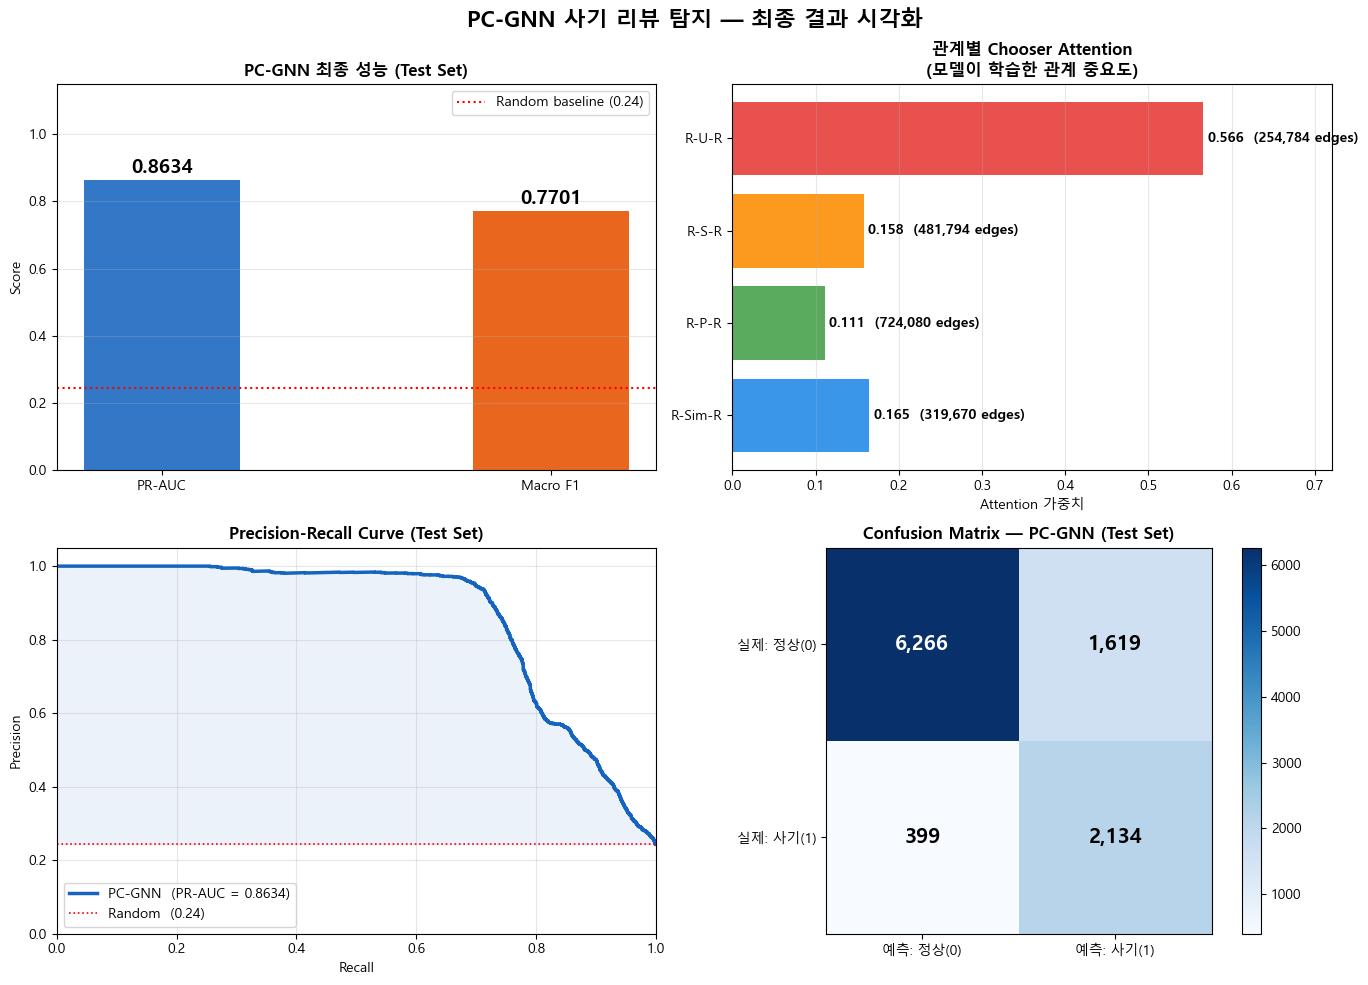

✅ 시각화 저장 완료: pcgnn_results.png


: 

In [ ]:
# [12] 최종 결과 시각화
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix

import platform
_font = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
plt.rcParams['font.family'] = _font
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PC-GNN 사기 리뷰 탐지 — 최종 결과 시각화', fontsize=16, fontweight='bold')

# ── (1) 최종 성능 요약 ──────────────────────────────────────────────
ax = axes[0, 0]
metrics = ['PR-AUC', 'Macro F1']
values  = [res_p_pr, res_p_f1]
colors  = ['#1565C0', '#E65100']
bars = ax.bar(metrics, values, color=colors, alpha=0.88, width=0.4)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('PC-GNN 최종 성능 (Test Set)', fontweight='bold')
ax.axhline(yt_p.mean(), color='red', linestyle=':', lw=1.5,
           label=f'Random baseline ({yt_p.mean():.2f})')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# ── (2) 관계별 Attention 가중치 ─────────────────────────────────────
ax = axes[0, 1]
colors_rel = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
edge_counts = [ei.size(1) for ei in edge_indices_pcgnn]
bars = ax.barh(REL_NAMES, attn_np, color=colors_rel, alpha=0.88)
for bar, val, ec in zip(bars, attn_np, edge_counts):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}  ({ec:,} edges)', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 0.72)
ax.set_xlabel('Attention 가중치')
ax.set_title('관계별 Chooser Attention\n(모델이 학습한 관계 중요도)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# ── (3) Precision-Recall Curve ──────────────────────────────────────
ax = axes[1, 0]
prec_p, rec_p, _ = precision_recall_curve(yt_p, yprob_p)
ax.plot(rec_p, prec_p, color='#1565C0', lw=2.5,
        label=f'PC-GNN  (PR-AUC = {res_p_pr:.4f})')
ax.axhline(yt_p.mean(), color='red', linestyle=':', lw=1.2,
           label=f'Random  ({yt_p.mean():.2f})')
ax.fill_between(rec_p, prec_p, yt_p.mean(), alpha=0.08, color='#1565C0')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Test Set)', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── (4) 혼동 행렬 ───────────────────────────────────────────────────
ax = axes[1, 1]
cm = confusion_matrix(yt_p, yp_p)
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['예측: 정상(0)', '예측: 사기(1)'], fontsize=10)
ax.set_yticklabels(['실제: 정상(0)', '실제: 사기(1)'], fontsize=10)
ax.set_title('Confusion Matrix — PC-GNN (Test Set)', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=15, fontweight='bold',
                color='white' if cm[i,j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.savefig('pcgnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 시각화 저장 완료: pcgnn_results.png')